In [1]:
import os
os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"
os.environ["SPARK_HOME"] = "/Users/kinchintong/project/tumult-labs/spark-4.0.1-bin-hadoop3"

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import findspark
findspark.init(os.environ["SPARK_HOME"])
from math import floor
from pyspark import SparkFiles
from pyspark.sql import SparkSession, types as T, functions as F
from tmlt.analytics.privacy_budget import PureDPBudget
from tmlt.analytics.protected_change import AddOneRow
from tmlt.analytics.query_builder import QueryBuilder
from tmlt.analytics.session import Session, ColumnType
from tmlt.analytics.keyset import KeySet
from functools import reduce
from tmlt.analytics import (
    AddOneRow,
    PureDPBudget,
    QueryBuilder,
    Session,
    AddRowsWithID,
)

from tmlt.analytics.truncation_strategy import TruncationStrategy

# Silence some Spark warnings
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', ResourceWarning)

findspark.init()

# Set up Spark
spark = (
    SparkSession.builder
    .appName("tpch-setup")
    .master("local[*]")           # drop if connecting to a cluster
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)
print("Spark version:", spark.version)

spark.sparkContext.setLogLevel("ERROR")

spark.conf.set("spark.sql.session.timeZone", "UTC")

# CREATE EMPTY TABLES (schema only) ----
def create_empty_tables():
    for t in TABLES:
        empty = spark.createDataFrame([], SCHEMAS[t])
        # managed Parquet tables; change to .format("delta") if using Delta
        #empty.write.mode("overwrite").format("parquet").saveAsTable(t)
    print(f"Created empty schema in database `{DB}`.")

# LOAD FROM CSV / .tbl (pipe-delimited with trailing '|') ----
def load_from_csv(src_dir: str):
    for t in TABLES:
        schema = SCHEMAS[t]
        path = f"{src_dir}/{t}.tbl"   # change to .csv if needed
        #only if the path exists
        if not os.path.exists(path):
            print(f"Path does not exist: {path}")
            continue
        
        print(f"Loading {t} from {path}...")

        # create a temporary wide schema of string columns (named) to absorb trailing '|'
        n_cols = len(schema.fields) + 1
        tmp_fields = [T.StructField(f"_c{i}", T.StringType(), True) for i in range(n_cols)]
        tmp_schema = T.StructType(tmp_fields)
        #print("tmp_schema:", tmp_schema)
        df_raw = (spark.read
                  .option("sep", "|")
                  .option("header", "false")
                  .option("mode", "PERMISSIVE")
                  .schema(tmp_schema)  # read wide to absorb trailing '|'
                  .csv(path))
        #print(f"Raw schema for {t}:")
        #df_raw.printSchema()
        
        # keep only first N columns and cast to target schema
        cols = df_raw.columns[:len(schema.fields)]
        df = df_raw.select([F.col(c).alias(schema.fields[i].name) for i, c in enumerate(cols)])
        # cast columns to target types
        for f in schema.fields:
            if isinstance(f.dataType, T.DateType):
                df = df.withColumn(f.name, F.to_date(F.col(f.name), "yyyy-MM-dd"))
            elif isinstance(f.dataType, T.DecimalType):
                df = df.withColumn(f.name, F.col(f.name).cast(f.dataType))
            elif isinstance(f.dataType, T.IntegerType):
                df = df.withColumn(f.name, F.col(f.name).cast("int"))
            # strings need no cast
        df.write.mode("overwrite").format("parquet").saveAsTable(t)
        print(f"Loaded {t} from {path}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/12/17 12:36:40 WARN Utils: Your hostname, kinchins-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.4.184 instead (on interface en0)
25/12/17 12:36:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/17 12:36:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/17 12:36:40 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.0.1


In [2]:
DB = "tpch"                          # change as you like

# Define canonical TPC-H schemas ----
dec = lambda p, s: T.DecimalType(p, s)
SCHEMAS = {
    "region":   T.StructType([
        T.StructField("r_regionkey", T.IntegerType(), False),
        T.StructField("r_name",      T.StringType(),  False),
        T.StructField("r_comment",   T.StringType(),  True),
    ]),
    "nation":   T.StructType([
        T.StructField("n_nationkey", T.IntegerType(), False),
        T.StructField("n_name",      T.StringType(),  False),
        T.StructField("n_regionkey", T.IntegerType(), False),
        T.StructField("n_comment",   T.StringType(),  True),
    ]),
    "part":     T.StructType([
        T.StructField("p_partkey",     T.IntegerType(), False),
        T.StructField("p_name",        T.StringType(),  False),
        T.StructField("p_mfgr",        T.StringType(),  False),
        T.StructField("p_brand",       T.StringType(),  False),
        T.StructField("p_type",        T.StringType(),  False),
        T.StructField("p_size",        T.IntegerType(), False),
        T.StructField("p_container",   T.StringType(),  False),
        T.StructField("p_retailprice", T.FloatType(),   False),
        T.StructField("p_comment",     T.StringType(),  True),
    ]),
    "supplier": T.StructType([
        T.StructField("s_suppkey",   T.IntegerType(), False),
        T.StructField("s_name",      T.StringType(),  False),
        T.StructField("s_address",   T.StringType(),  False),
        T.StructField("s_nationkey", T.IntegerType(), False),
        T.StructField("s_phone",     T.StringType(),  False),
        T.StructField("s_acctbal",   T.FloatType(),   False),
        T.StructField("s_comment",   T.StringType(),  True),
    ]),
    "partsupp": T.StructType([
        T.StructField("ps_partkey",    T.IntegerType(), False),
        T.StructField("ps_suppkey",    T.IntegerType(), False),
        T.StructField("ps_availqty",   T.IntegerType(), False),
        T.StructField("ps_supplycost", T.FloatType(),   False),
        T.StructField("ps_comment",    T.StringType(),  True),
    ]),
    "customer": T.StructType([
        T.StructField("c_custkey",   T.IntegerType(), False),
        T.StructField("c_name",      T.StringType(),  False),
        T.StructField("c_address",   T.StringType(),  False),
        T.StructField("c_nationkey", T.IntegerType(), False),
        T.StructField("c_phone",     T.StringType(),  False),
        T.StructField("c_acctbal",   T.FloatType(),   False),
        T.StructField("c_mktsegment",T.StringType(),  True),
        T.StructField("c_comment",   T.StringType(),  True),
    ]),
    "orders":   T.StructType([
        T.StructField("o_orderkey",     T.IntegerType(), False),
        T.StructField("o_custkey",      T.IntegerType(), False),
        T.StructField("o_orderstatus",  T.StringType(),  False),
        T.StructField("o_totalprice",   T.FloatType(),   False),
        T.StructField("o_orderdate",    T.DateType(),    False),
        T.StructField("o_orderpriority",T.StringType(),  False),
        T.StructField("o_clerk",        T.StringType(),  False),
        T.StructField("o_shippriority", T.IntegerType(), False),
        T.StructField("o_comment",      T.StringType(),  True),
    ]),
    "lineitem": T.StructType([
        T.StructField("l_orderkey",      T.IntegerType(), False),
        T.StructField("l_partkey",       T.IntegerType(), False),
        T.StructField("l_suppkey",       T.IntegerType(), False),
        T.StructField("l_linenumber",    T.IntegerType(), False),
        T.StructField("l_quantity",      T.FloatType(),   False),
        T.StructField("l_extendedprice", T.FloatType(),   False),
        T.StructField("l_discount",      T.FloatType(),   False),
        T.StructField("l_tax",           T.FloatType(),   False),
        T.StructField("l_returnflag",    T.StringType(),  False),
        T.StructField("l_linestatus",    T.StringType(),  False),
        T.StructField("l_shipdate",      T.DateType(),    False),
        T.StructField("l_commitdate",    T.DateType(),    False),
        T.StructField("l_receiptdate",   T.DateType(),    False),
        T.StructField("l_shipinstruct",  T.StringType(),  False),
        T.StructField("l_shipmode",      T.StringType(),  False),
        T.StructField("l_comment",       T.StringType(),  True),
    ]),
}
TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
spark.sql(f"CREATE DATABASE IF NOT EXISTS {DB}")
spark.catalog.setCurrentDatabase(DB)

create_empty_tables()


Created empty schema in database `tpch`.


In [3]:
SRC_CSV_DIR = "./raw"    # where *.tbl live
load_from_csv(SRC_CSV_DIR)

# Quick smoke test:
spark.sql("SHOW TABLES").show(truncate=False)
# show record count for each table
for t in TABLES:
    print(f"Table {t} has {spark.sql(f'SELECT count(*) FROM {t}').collect()[0][0]} records.")

Loading region from ./raw/region.tbl...
Loaded region from ./raw/region.tbl
Loading nation from ./raw/nation.tbl...
Loaded nation from ./raw/nation.tbl
Loading part from ./raw/part.tbl...


Loaded part from ./raw/part.tbl
Loading supplier from ./raw/supplier.tbl...
Loaded supplier from ./raw/supplier.tbl
Loading partsupp from ./raw/partsupp.tbl...


Loaded partsupp from ./raw/partsupp.tbl
Loading customer from ./raw/customer.tbl...
Loaded customer from ./raw/customer.tbl
Loading orders from ./raw/orders.tbl...


Loaded orders from ./raw/orders.tbl
Loading lineitem from ./raw/lineitem.tbl...


Loaded lineitem from ./raw/lineitem.tbl
+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
|tpch     |customer |false      |
|tpch     |lineitem |false      |
|tpch     |nation   |false      |
|tpch     |orders   |false      |
|tpch     |part     |false      |
|tpch     |partsupp |false      |
|tpch     |region   |false      |
|tpch     |supplier |false      |
+---------+---------+-----------+

Table region has 5 records.
Table nation has 25 records.
Table part has 200000 records.
Table supplier has 10000 records.
Table partsupp has 800000 records.
Table customer has 150000 records.
Table orders has 1500000 records.
Table lineitem has 6001215 records.


***
## TPC-H Queries Evaluated

- **Q1 - Pricing Summary Report Query**<br>
    This query reports the amount of business that was billed, shipped, and returned.

- **Q4 - Order Priority Checking Query**<br>
    This query determines how well the order priority system is working and gives an assessment of customer satisfac-
tion.

- **Q13 - Customer Distribution Query**<br>
    This query seeks relationships between customers and the size of their orders.

- **Q16 - Parts/Supplier Relationship Query**<br>
    This query finds out how many suppliers can supply parts with given attributes. It might be used, for example, to
determine whether there is a sufficient number of suppliers for heavily ordered parts.

## PrivateSQL paper evaluation
### Dataset: TPC-H
### Privacy Policy: Customer
### Privacy Budget ϵ: 1.0

privacy model:
customer table is private
orders table have foeign key of customer table (custkey)
lineitem table have forign key of orders table (orderkey)

In [4]:
SRC_CSV_DIR = "./raw"
dataframes = {}
tpch_query_results = {}

TABLES = ["region","nation","part","supplier","partsupp","customer","orders","lineitem"]
for table_name in TABLES:
    path = f"{SRC_CSV_DIR}/{table_name}.tbl"
    schema = SCHEMAS[table_name]
    dataframes[table_name] = (spark.read
                .option("sep", "|")
                .option("header", "false")
                .option("mode", "PERMISSIVE")
                .schema(schema)
                .csv(path))

#needed for q1
lineitem_with_disc_view = (dataframes["lineitem"]
    .withColumn("disc_price",
                (dataframes["lineitem"]["l_extendedprice"].cast("double") * (1.0 - dataframes["lineitem"]["l_discount"].cast("double"))))
    .withColumn("charge",
                (dataframes["lineitem"]["l_extendedprice"].cast("double") * (1.0 - dataframes["lineitem"]["l_discount"].cast("double")) * (1.0 + dataframes["lineitem"]["l_tax"].cast("double"))))

)
dataframes["lineitem_with_disc"] = lineitem_with_disc_view

WORD1 = 'special'
WORD2 = 'requests'
q13_view = f"""
SELECT
  c.c_custkey,
  COUNT(o.o_orderkey) AS c_count
FROM customer c
LEFT JOIN orders o
  ON  o.o_custkey = c.c_custkey
  AND o_comment NOT LIKE '%{WORD1}%{WORD2}%'
GROUP BY c.c_custkey;
"""

V_q13 = spark.sql(q13_view)
dataframes["V_q13"] = V_q13

q4_view = f"""
SELECT DISTINCT
    o.o_orderkey,
    o.o_orderpriority
FROM orders o
JOIN lineitem l
    ON l.l_orderkey = o.o_orderkey
WHERE l.l_commitdate < l.l_receiptdate;
"""

V_q4 = spark.sql(q4_view)
dataframes["V_q4"] = V_q4

q16_view = """
SELECT DISTINCT
  p.p_brand,
  p.p_type,
  p.p_size,
  ps.ps_suppkey
FROM part p
JOIN partsupp ps
  ON p.p_partkey = ps.ps_partkey
JOIN supplier s
  ON s.s_suppkey = ps.ps_suppkey
WHERE s.s_comment NOT LIKE '%Customer%Complaints%'
"""
V_q16 = spark.sql(q16_view)
dataframes["V_q16"] = V_q16

for table_name in dataframes:
    print(f"Schema for table: {table_name}")
    dataframes[table_name].show(5)


budget = PureDPBudget(float("inf"))
#budget = PureDPBudget(3)

id_space = "q1_id_space"

session = (
    Session.Builder()
    .with_privacy_budget(budget)
    .with_id_space(id_space)
    .with_private_dataframe(
        "V_q4",
        dataframes["V_q4"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "V_q13",
        dataframes["V_q13"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "V_q16",
        dataframes["V_q16"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "lineitem_with_disc",
        dataframes["lineitem_with_disc"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "lineitem",
        dataframes["lineitem"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "orders",
        dataframes["orders"],
        protected_change=AddOneRow(),
    )
    .with_private_dataframe(
        "customer",
        dataframes["customer"],
        protected_change=AddOneRow(),
    )
    .with_public_dataframe(
        "region",
        dataframes["region"],
    )
    .with_public_dataframe(
        "nation",
        dataframes["nation"],
    )
    .with_public_dataframe(
        "part",
        dataframes["part"],
    )
    .with_public_dataframe(
        "supplier",
        dataframes["supplier"],
    )
    .with_public_dataframe(
        "partsupp",
        dataframes["partsupp"],
    )
    .build()
)

print(f"Private dataframes: {session.private_sources}")
print(f"Public dataframes: {session.public_sources}")
for source_id in session.private_sources:
    print(f"Schema for {source_id}:")
    x = session.get_schema(source_id)
    print(x)


Schema for table: region
+-----------+-----------+--------------------+
|r_regionkey|     r_name|           r_comment|
+-----------+-----------+--------------------+
|          0|     AFRICA|lar deposits. bli...|
|          1|    AMERICA|hs use ironic, ev...|
|          2|       ASIA|ges. thinly even ...|
|          3|     EUROPE|ly final courts c...|
|          4|MIDDLE EAST|uickly special ac...|
+-----------+-----------+--------------------+

Schema for table: nation
+-----------+---------+-----------+--------------------+
|n_nationkey|   n_name|n_regionkey|           n_comment|
+-----------+---------+-----------+--------------------+
|          0|  ALGERIA|          0| haggle. carefull...|
|          1|ARGENTINA|          1|al foxes promise ...|
|          2|   BRAZIL|          1|y alongside of th...|
|          3|   CANADA|          1|eas hang ironic, ...|
|          4|    EGYPT|          4|y above the caref...|
+-----------+---------+-----------+--------------------+
only showing 

+----------+---------------+
|o_orderkey|o_orderpriority|
+----------+---------------+
|        34|       3-MEDIUM|
|        65|       1-URGENT|
|       101|       3-MEDIUM|
|       133|       1-URGENT|
|       193|       1-URGENT|
+----------+---------------+
only showing top 5 rows
Schema for table: V_q16
+--------+--------------------+------+----------+
| p_brand|              p_type|p_size|ps_suppkey|
+--------+--------------------+------+----------+
|Brand#12|LARGE POLISHED NI...|    48|        21|
|Brand#13| LARGE BRUSHED STEEL|     8|      5035|
|Brand#14|ECONOMY POLISHED ...|    24|        79|
|Brand#32|PROMO ANODIZED STEEL|     1|      5125|
|Brand#34|MEDIUM ANODIZED B...|    25|       234|
+--------+--------------------+------+----------+
only showing top 5 rows
Private dataframes: ['customer', 'orders', 'lineitem', 'lineitem_with_disc', 'V_q16', 'V_q13', 'V_q4']
Public dataframes: ['region', 'nation', 'part', 'supplier', 'partsupp']
Schema for customer:
{'c_custkey': ColumnD

In [5]:
def query_dp_eval(eps: PureDPBudget, session: Session, query_num, query_dp_run, num_runs: int = 1, start_run: int = 0):
  for run in range(start_run,num_runs):
    print(f"Running Q1 DP run {run+1}/{num_runs} with epsilon={eps.epsilon}...")
    runx = query_dp_run(eps, session)

    output_file = f"./output/dp/q{query_num}/q{query_num}_dp_result_eps_{eps.epsilon}_runs_{run+1}_csv"

    runx.coalesce(1).write \
      .mode("overwrite") \
      .option("header", "true") \
      .csv(output_file)

***
Query 1

In [6]:
def q1_dp_run(eps: PureDPBudget, session: Session):
  
  #1) Create V_q1 with casts + derived columns
  DELTA = 90

  q1_view = (
    QueryBuilder("lineitem_with_disc")
      .select([
          "l_returnflag",
          "l_linestatus",
          "l_quantity",
          "l_extendedprice",
          "l_discount",
          "l_tax",
          "l_shipdate",
          "disc_price",
          "charge",
      ])
  )

  # delete V_q1 only if it exists to avoid errors
  try:
    session.delete_view("V_q1")
  except Exception as e:
    pass

  session.create_view(source_id="V_q1", query_expr=q1_view, cache=True)

  #2) Group + filter (use Spark-friendly interval)
  groupby_keys = KeySet.from_dict({
      "l_returnflag": ["A", "N", "R"],
      "l_linestatus": ["F", "O"],
  })

  q1_linear_grouped = (
      QueryBuilder("V_q1")
        .filter(f"l_shipdate <= DATE '1998-12-01' - INTERVAL {DELTA} DAYS")
        .groupby(groupby_keys)
  )

  q_count_order    = q1_linear_grouped.count(name="count_order")
  dp_count_order    = session.evaluate(q_count_order,    privacy_budget=eps)



  keys = ["l_returnflag", "l_linestatus"]


  return dp_count_order

    

***
Query 4

In [7]:
def q4_dp_run(eps: PureDPBudget, session: Session):
    print("Building Q4 deduped view V_q4...")
    from tmlt.analytics.query_builder import QueryBuilder

    # lineitem filtered
    q_lineitem_filtered = (
        QueryBuilder("lineitem")
        .filter("l_commitdate < l_receiptdate")
        .select(["l_orderkey"])
        .rename({"l_orderkey": "orderkey"})
    )

    # orders columns (include orderdate so you DON'T need to join orders again later)
    q_orders = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_orderpriority", "o_orderdate"])
        .rename({"o_orderkey": "orderkey"})
    )

    # join
    q4_view = q_orders.join_private(
        right_operand=q_lineitem_filtered,
        join_columns=["orderkey"],
        truncation_strategy_left=TruncationStrategy.DropExcess(1),
        truncation_strategy_right=TruncationStrategy.DropExcess(1),
    ).select(["orderkey", "o_orderpriority", "o_orderdate"])

    # create session view
    try:
        session.delete_view("V_q4")
    except Exception:
        pass

    session.create_view(source_id="V_q4", query_expr=q4_view, cache=True)

    start_date = "1993-07-01"
    eps = PureDPBudget(epsilon=1.0)

    groupby_keys = KeySet.from_dict({
        "o_orderpriority": ["1-URGENT", "2-HIGH", "3-MEDIUM", "4-NOT SPECIFIED", "5-LOW"]
    })

    q_orders_2 = (
        QueryBuilder("orders")
        .select(["o_orderkey", "o_orderdate"])
        .filter(
                f"o_orderdate >= DATE '{start_date}' AND "
                f"o_orderdate <  DATE '{start_date}' + INTERVAL 3 MONTH"
            )
        .rename({"o_orderkey": "orderkey"})
    )
    q4_1 = (
        QueryBuilder("V_q4").join_private(
            right_operand=q_orders_2,
            join_columns=["orderkey"],
            truncation_strategy_left=TruncationStrategy.DropExcess(1),
            truncation_strategy_right=TruncationStrategy.DropExcess(1),
        )
        .select(["o_orderpriority"])
        .groupby(groupby_keys)
    )

    q4_count = q4_1.count(name="order_count")

    q4_dp_result = session.evaluate(q4_count, privacy_budget=eps)
    ##q4_dp_result.orderBy("o_orderpriority").show(truncate=False)
    #q4_dp_result.show(truncate=False)

    return q4_dp_result


***
Query 13

In [8]:
def q13_dp_run(eps: PureDPBudget, session: Session):


    count_keys_df = (
        dataframes["V_q13"]
             .select(F.col("c_count"))
             .distinct()
    )
    c_count_keyset = KeySet.from_dataframe(count_keys_df)


    """
    SELECT
    c_count,
    COUNT(*) AS custdist
    FROM V_q13
    GROUP BY c_count
    ORDER BY custdist DESC, c_count DESC;
    """

    q13_grouped = (
        QueryBuilder("V_q13")
            .groupby(c_count_keyset)
            .count(name="custdist")
    )

    dp_result = session.evaluate(q13_grouped, privacy_budget=eps)
    #dp_result.show(truncate=False)

    return dp_result


***
Query 16

In [9]:
def q16_dp_run(eps: PureDPBudget, session: Session):
    
    '''
    SELECT
        p_brand, p_type, p_size,
        COUNT(*) AS supplier_cnt
    FROM V_q16
    WHERE p_brand <> '{BRAND}'
        AND p_type NOT LIKE '{TYPE_PREFIX}%'
        AND p_size IN ({sizes_csv})
    GROUP BY p_brand, p_type, p_size
    ORDER BY supplier_cnt DESC, p_brand, p_type, p_size
    '''

    syllable1 = ["STANDARD", "SMALL", "MEDIUM", "LARGE", "ECONOMY", "PROMO"]
    syllable2 = ["ANODIZED", "BURNISHED", "PLATED", "POLISHED", "BRUSHED"]
    syllable3 = ["TIN", "NICKEL", "BRASS", "STEEL", "COPPER"]

    TPC_H_TYPES = [
        f"{s1} {s2} {s3}"
        for s1 in syllable1
        for s2 in syllable2
        for s3 in syllable3
    ]

    groupby_keys = KeySet.from_dict({
        "p_brand": ["Brand#11", "Brand#12", "Brand#13","Brand#14", "Brand#15", 
                    "Brand#21", "Brand#22", "Brand#23","Brand#24", "Brand#25",
                    "Brand#31", "Brand#32", "Brand#33","Brand#34", "Brand#35",
                    "Brand#41", "Brand#42", "Brand#43","Brand#44", "Brand#45",
                    "Brand#51", "Brand#52", "Brand#53","Brand#54", "Brand#55"],
        "p_type": [
                        f"{s1} {s2} {s3}"
                        for s1 in syllable1
                        for s2 in syllable2
                        for s3 in syllable3
                    ],
        "p_size": list(range(1, 51)),
    })

    BRAND = "Brand#12"
    TYPE_PREFIX = "LARGE ANODIZED"
    SIZES = [3, 6, 9, 12, 18, 24, 36, 48]
    sizes_csv = ",".join(map(str, SIZES))

    q16_filtered = (
        QueryBuilder("V_q16")
          .filter(f"p_brand <> '{BRAND}' AND p_type NOT LIKE '{TYPE_PREFIX}%' AND p_size IN ({sizes_csv})")
          .select(["p_brand", "p_type", "p_size"])
          .groupby(groupby_keys)
          .count(name="supplier_cnt")
    )

    dp_result = session.evaluate(q16_filtered, privacy_budget=eps)
    #dp_result.show(truncate=False)

    return dp_result


In [10]:
for run in [1000]:
    eps = PureDPBudget(1.0 )
    query_dp_eval(eps, session, query_num=1, query_dp_run=q1_dp_run, num_runs=run)
    query_dp_eval(eps, session, query_num=4, query_dp_run=q4_dp_run, num_runs=run)
    query_dp_eval(eps, session, query_num=13, query_dp_run=q13_dp_run, num_runs=run)
    query_dp_eval(eps, session, query_num=16, query_dp_run=q16_dp_run, num_runs=run)

Running Q1 DP run 1/1000 with epsilon=1...
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15fe7eea0>
create_view constraints= []
create_view ref = TableReference(TemporaryTable(4359218304))
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view accountant.d_in= {NamedTable(name='V_q4'): 1, NamedTable(name='V_q13'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='orders'): 1, NamedTable(name='customer'): 1, TemporaryTable(5904003440): 1, TemporaryTable(4359218304): 1, NamedTable(name='V_q1'): 1}
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15fe7eba0>
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15d626300>
T3 - d_in=

Running Q1 DP run 2/1000 with epsilon=1...
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15c165f70>
create_view constraints= []
create_view ref = TableReference(TemporaryTable(5872953600))
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view accountant.d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='customer'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='orders'): 1, TemporaryTable(5903999360): 1, TemporaryTable(5872953600): 1, NamedTable(name='V_q1'): 1}
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15ef0faa0>
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15d70e900>
T3 - d_in=

Running Q1 DP run 3/1000 with epsilon=1...
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15f448bc0>
create_view constraints= []
create_view ref = TableReference(TemporaryTable(4359027936))
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view accountant.d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='customer'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904042080): 1, TemporaryTable(4359027936): 1, NamedTable(name='V_q1'): 1}
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15f448890>
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15c522780>
T3 - d_in=

Running Q1 DP run 4/1000 with epsilon=1...
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15f4e2ae0>
create_view constraints= []
create_view ref = TableReference(TemporaryTable(5893925168))
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view accountant.d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='customer'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904048704): 1, TemporaryTable(5893925168): 1, NamedTable(name='V_q1'): 1}
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15f4e10d0>
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15d5154c0>
T3 - d_in=

Running Q1 DP run 5/1000 with epsilon=1...
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15bf3cad0>
create_view constraints= []
create_view ref = TableReference(TemporaryTable(5839780992))
create_view accountant= <tmlt.core.measurements.interactive_measurements.PrivacyAccountant object at 0x15d1c2810>
create_view accountant.d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='customer'): 1, NamedTable(name='V_q4'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904087568): 1, TemporaryTable(5839780992): 1, NamedTable(name='V_q1'): 1}
create_view transformation= <tmlt.core.transformations.chaining.ChainTT object at 0x15ee9b440>
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15d29dd90>
T3 - d_in=

...

Running Q1 DP run 996/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15fe90980>
T3 - d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='V_q1'): 1, NamedTable(name='customer'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904575296): 1, TemporaryTable(5904567664): 1, TemporaryTable(5904084352): 1, TemporaryTable(5839047136): 1, TemporaryTable(5873014960): 1, TemporaryTable(5904085264): 4, TemporaryTable(5904073792): 4, TemporaryTable(5893300080): 4, NamedTable(name='V_q4'): 4}


Running Q1 DP run 997/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x103d17cb0>
T3 - d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='V_q1'): 1, NamedTable(name='customer'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904575296): 1, TemporaryTable(5904567664): 1, TemporaryTable(5904084352): 1, TemporaryTable(5839047136): 1, TemporaryTable(5873014960): 1, TemporaryTable(5904085264): 4, TemporaryTable(5904073792): 4, TemporaryTable(5893300080): 4, NamedTable(name='V_q4'): 4}


Running Q1 DP run 998/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15ff241d0>
T3 - d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='V_q1'): 1, NamedTable(name='customer'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904575296): 1, TemporaryTable(5904567664): 1, TemporaryTable(5904084352): 1, TemporaryTable(5839047136): 1, TemporaryTable(5873014960): 1, TemporaryTable(5904085264): 4, TemporaryTable(5904073792): 4, TemporaryTable(5893300080): 4, NamedTable(name='V_q4'): 4}


Running Q1 DP run 999/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15f4e13a0>
T3 - d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='V_q1'): 1, NamedTable(name='customer'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904575296): 1, TemporaryTable(5904567664): 1, TemporaryTable(5904084352): 1, TemporaryTable(5839047136): 1, TemporaryTable(5873014960): 1, TemporaryTable(5904085264): 4, TemporaryTable(5904073792): 4, TemporaryTable(5893300080): 4, NamedTable(name='V_q4'): 4}


Running Q1 DP run 1000/1000 with epsilon=1...
T1 - evaluate()
T2 - measurement= <tmlt.core.measurements.chaining.ChainTM object at 0x15fe8a120>
T3 - d_in= {NamedTable(name='V_q13'): 1, NamedTable(name='lineitem_with_disc'): 1, NamedTable(name='V_q16'): 1, NamedTable(name='lineitem'): 1, NamedTable(name='V_q1'): 1, NamedTable(name='customer'): 1, NamedTable(name='orders'): 1, TemporaryTable(5904575296): 1, TemporaryTable(5904567664): 1, TemporaryTable(5904084352): 1, TemporaryTable(5839047136): 1, TemporaryTable(5873014960): 1, TemporaryTable(5904085264): 4, TemporaryTable(5904073792): 4, TemporaryTable(5893300080): 4, NamedTable(name='V_q4'): 4}


***
## Calcuate Error

In [11]:
from typing import List


def compute_errors_privatesql_style(
    dp_df,
    truth_df,
    keys: List[str],
    metric: str = "count_order",
    run_col: str = "run_id",
    join_type: str = "left",
    truth_missing_as_zero: bool = True,
):
    """
    Compute PrivateSQL-style errors per output group per run.
      Qerror(y, y~)   = |y - y~|
      RelError(y, y~) = |y - y~| / max(50, y)

    Returns columns:
      run_id,
      keys,
      <metric>_truth,
      <metric>_dp,
      qerror_<metric>,
      relerror_<metric>
    """

    # Prepare DP side
    dp = (
        dp_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_dp")
    )
    dp.show(5)

    # Prepare truth side
    tr = (
        truth_df
        .withColumn(metric, F.col(metric).cast("double"))
        .withColumnRenamed(metric, f"{metric}_truth")
    )

    tr.show(5)
    
    joined = dp.alias("dp").join(tr.alias("tr"), on=keys, how=join_type)

    if truth_missing_as_zero:
        joined = joined.withColumn(
            f"{metric}_truth",
            F.coalesce(F.col(f"{metric}_truth"), F.lit(0.0))
        )

    # Absolute error |y - y~|
    joined = joined.withColumn(
        f"qerror",
        F.abs(F.col(f"{metric}_truth") - F.col(f"{metric}_dp"))
    )

    # Relative error |y - y~| / max(50, y)
    joined = joined.withColumn(
        f"relerror",
        F.col(f"qerror") /
        F.greatest(F.lit(50.0), F.col(f"{metric}_truth"))
    )

    return joined.select(
        run_col,
        *keys,
        f"{metric}_truth",
        f"{metric}_dp",
        f"qerror",
        f"relerror",
    )


In [12]:
#Q1 

# -------------------------
# CONFIG
# -------------------------
keys = ["l_returnflag", "l_linestatus"]
metrics = ["count_order"]
metric_casts = {"count_order": "long"}  # important: count is integer

eps_val = 1
truth_path = "./output/no_dp/q1_result_csv"

# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "count_order")
    .withColumn("count_order", F.col("count_order").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp/q1/q1_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "count_order")
    .withColumn("count_order", F.col("count_order").cast("long"))
)
print("Q1")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric="count_order",
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

overall.show(truncate=False)
tpch_query_results["Q1"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q1
Distinct runs = 1000
+------+------------+------------+--------------+
|run_id|l_returnflag|l_linestatus|count_order_dp|
+------+------------+------------+--------------+
|   103|           A|           F|     1478493.0|
|   103|           A|           O|          -2.0|
|   103|           N|           F|       38854.0|
|   103|           N|           O|     2920375.0|
|   103|           R|           F|     1478872.0|
+------+------------+------------+--------------+
only showing top 5 rows
+------------+------------+-----------------+
|l_returnflag|l_linestatus|count_order_truth|
+------------+------------+-----------------+
|           A|           F|        1478493.0|
|           N|           F|          38854.0|
|           N|           O|        2920374.0|
|           R|           F|        1478870.0|
+------------+------------+-----------------+

+------+------------+------------+-----------------+--------------+------+---------------------+
|run_id|l_returnflag|l_linestatus|co

In [13]:
#Q4

# -------------------------
# CONFIG
# -------------------------
keys = ["o_orderpriority"]
metrics = "order_count"

eps_val = 1
truth_path = "./output/no_dp/q4_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "order_count")
    .withColumn("order_count", F.col("order_count").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp/q4/q4_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "order_count")
    .withColumn("order_count", F.col("order_count").cast("long"))
)
print("Q4")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q4"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }

overall.show(truncate=False)

Q4
Distinct runs = 1000
+------+---------------+--------------+
|run_id|o_orderpriority|order_count_dp|
+------+---------------+--------------+
|  1000|       1-URGENT|       10595.0|
|  1000|         2-HIGH|       10501.0|
|  1000|       3-MEDIUM|       10442.0|
|  1000|4-NOT SPECIFIED|       10545.0|
|  1000|          5-LOW|       10494.0|
+------+---------------+--------------+
only showing top 5 rows
+---------------+-----------------+
|o_orderpriority|order_count_truth|
+---------------+-----------------+
|       1-URGENT|          10594.0|
|         2-HIGH|          10476.0|
|       3-MEDIUM|          10410.0|
|4-NOT SPECIFIED|          10556.0|
|          5-LOW|          10487.0|
+---------------+-----------------+

+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|9.927399999999995    |9.450213549803646E-4   |
+---------------------+-----------------------+



In [14]:
#Q13

# -------------------------
# CONFIG
# -------------------------
keys = ["c_count"]
metrics = "custdist"

eps_val = 1
truth_path = "./output/no_dp/q13_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp/q13/q13_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "custdist")
    .withColumn("custdist", F.col("custdist").cast("long"))
)
print("Q13")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q13"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q13
Distinct runs = 1000
+------+-------+-----------+
|run_id|c_count|custdist_dp|
+------+-------+-----------+
|   168|      0|    50007.0|
|   168|      1|       17.0|
|   168|      2|      134.0|
|   168|      3|      413.0|
|   168|      4|     1008.0|
+------+-------+-----------+
only showing top 5 rows
+-------+--------------+
|c_count|custdist_truth|
+-------+--------------+
|      0|       50005.0|
|      9|        6641.0|
|     10|        6532.0|
|     11|        6014.0|
|      8|        5937.0|
+-------+--------------+
only showing top 5 rows
+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|0.8487857142857165   |0.00464267612027022    |
+---------------------+-----------------------+



In [15]:
#Q16

# -------------------------
# CONFIG
# -------------------------
keys = ["p_brand","p_type","p_size"]
metrics = "supplier_cnt"

eps_val = 1
truth_path = "./output/no_dp/q16_result_csv"
# -------------------------
# LOAD TRUTH
# -------------------------
truth = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(truth_path)
    .select(*keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)

# -------------------------
# LOAD RUNS (ALL 1000)
# -------------------------
runs_glob = f"./output/dp/q16/q16_dp_result_eps_{eps_val}_runs_*_csv"

dp_runs = (spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(runs_glob)
    .withColumn(
        "run_id",
        F.regexp_extract(F.input_file_name(), r"runs_(\d+)_csv", 1).cast("int")
    )
    .select("run_id", *keys, "supplier_cnt")
    .withColumn("supplier_cnt", F.col("supplier_cnt").cast("long"))
)
print("Q16")
print("Distinct runs =", dp_runs.select("run_id").distinct().count())

err_df = compute_errors_privatesql_style(
    dp_df=dp_runs,
    truth_df=truth,
    keys=keys,
    metric=metrics,
    run_col="run_id",
    join_type="left",
    truth_missing_as_zero=True,
)

#err_df.show(truncate=False)

per_run = err_df.groupBy("run_id").agg(
    F.avg("qerror").alias("avg_qerror_per_run"),
    F.avg("relerror").alias("avg_relerror_per_run"),
).orderBy("run_id")

#per_run.show(20, truncate=False)

overall = per_run.agg(
    F.avg("avg_qerror_per_run").alias("mean_qerror_over_runs"),
    F.avg("avg_relerror_per_run").alias("mean_relerror_over_runs"),
)

tpch_query_results["Q16"] ={
        "mean_qerror_over_runs": float(overall.collect()[0]["mean_qerror_over_runs"]),
        "mean_relerror_over_runs": float(overall.collect()[0]["mean_relerror_over_runs"]),
    }


overall.show(truncate=False)

Q16


Distinct runs = 1000
+------+--------+--------------------+------+---------------+
|run_id| p_brand|              p_type|p_size|supplier_cnt_dp|
+------+--------+--------------------+------+---------------+
|   500|Brand#11|ECONOMY ANODIZED ...|     1|            0.0|
|   500|Brand#11|ECONOMY ANODIZED ...|     3|            4.0|
|   500|Brand#11|ECONOMY ANODIZED ...|    13|            0.0|
|   500|Brand#11|ECONOMY ANODIZED ...|    14|            0.0|
|   500|Brand#11|ECONOMY ANODIZED ...|    17|            0.0|
+------+--------+--------------------+------+---------------+
only showing top 5 rows
+--------+--------------------+------+------------------+
| p_brand|              p_type|p_size|supplier_cnt_truth|
+--------+--------------------+------+------------------+
|Brand#25| PROMO BRUSHED STEEL|    24|              28.0|
|Brand#41|ECONOMY ANODIZED ...|    48|              28.0|
|Brand#41|  MEDIUM BRUSHED TIN|     3|              28.0|
|Brand#11|STANDARD BURNISHE...|    36|           

+---------------------+-----------------------+
|mean_qerror_over_runs|mean_relerror_over_runs|
+---------------------+-----------------------+
|0.8509771413333347   |0.017019542826654063   |
+---------------------+-----------------------+



***


opendp eval with TPCH Results Summary:
Queries evaluated: ['Q1', 'Q4', 'Q13', 'Q16']
Average Qerror per query: [0.8853333333333331, 9.927399999999995, 0.8487857142857165, 0.8509771413333347]
Average RelError per query: [0.005943950525281636, 0.0009450213549803646, 0.00464267612027022, 0.017019542826654063]


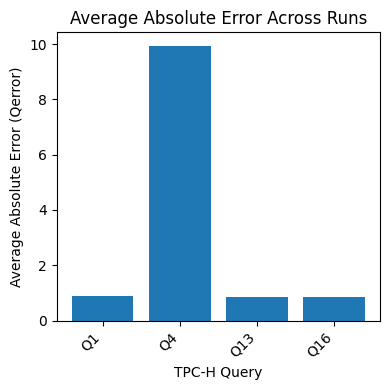

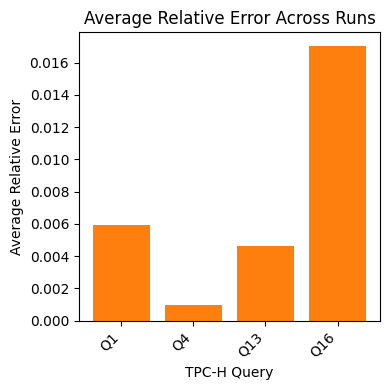

In [16]:
print("opendp eval with TPCH Results Summary:")
os.makedirs("./output/figs", exist_ok=True)

import matplotlib.pyplot as plt

# Use a stable list of labels (convert to strings) and numeric positions for plotting
queries = list(tpch_query_results.keys())
queries_label = [str(q) for q in queries]
print("Queries evaluated:", queries_label)

avg_qerror = [tpch_query_results[q]["mean_qerror_over_runs"] for q in queries]
print("Average Qerror per query:", avg_qerror)
avg_relerror = [tpch_query_results[q]["mean_relerror_over_runs"] for q in queries]
print("Average RelError per query:", avg_relerror)

positions = list(range(len(queries_label)))

# Absolute error bar plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(positions, avg_qerror, color='tab:blue')
ax.set_xticks(positions)
ax.set_xticklabels(queries_label, rotation=45, ha='right')
ax.set_xlabel("TPC-H Query")
ax.set_ylabel("Average Absolute Error (Qerror)")
ax.set_title("Average Absolute Error Across Runs")
plt.tight_layout()
plt.show()

# Relative error bar plot
fig2, ax2 = plt.subplots(figsize=(4, 4))
ax2.bar(positions, avg_relerror, color='tab:orange')
ax2.set_xticks(positions)
ax2.set_xticklabels(queries_label, rotation=45, ha='right')
ax2.set_xlabel("TPC-H Query")
ax2.set_ylabel("Average Relative Error")
ax2.set_title("Average Relative Error Across Runs")
plt.tight_layout()
plt.show()